# 📘 智能体架构 2：工具使用

本笔记本介绍第二种智能体架构，也可以说是最具变革性的架构之一：**工具使用**。这一模式是连接大型语言模型推理能力与真实动态世界的桥梁。

没有工具，LLM 是一个封闭系统，受限于冻结在其训练数据中的知识。它无法知道今天的天气、股票的当前价格，或公司数据库中订单的状态。通过赋予智能体使用工具的能力，我们使其能够克服这一根本限制，允许它查询 API、搜索数据库并访问实时信息，以提供不仅经过推理，而且符合事实、及时且相关的答案。

### 定义
**工具使用**架构为基于 LLM 的智能体配备了调用外部函数或 API（即"工具"）的能力。智能体自主决定何时仅靠其内部知识无法回答用户的查询，并确定调用哪个工具来查找必要信息。

### 高层工作流程

1. **接收查询：** 智能体接收来自用户的请求。
2. **决策：** 智能体分析查询及其可用工具。它决定是否需要工具来准确回答问题。
3. **行动：** 如果需要工具，智能体格式化对该工具的调用（例如，具有正确参数的特定函数）。
4. **观察：** 系统执行工具调用，结果（即"观察"）返回给智能体。
5. **综合：** 智能体将工具的输出集成到其推理过程中，为用户生成最终的、有依据的答案。

### 适用场景 / 应用
* **研究助手：** 使用网络搜索 API 回答需要最新信息的问题。
* **企业助手：** 查询内部公司数据库以回答诸如"上周有多少新用户注册？"等问题。
* **科学与数学任务：** 使用计算器或 WolframAlpha 等计算引擎进行 LLM 通常难以处理的精确计算。

### 优缺点
* **优点：**
    * **事实依据：** 通过获取真实、实时的数据大幅减少幻觉。
    * **可扩展性：** 可以简单地添加新工具来持续扩展智能体的能力。
* **缺点：**
    * **集成开销：** 需要仔细的"管道"工作来定义工具、处理 API 密钥和管理潜在的工具故障。
    * **工具信任：** 智能体答案的质量取决于其所使用工具的可靠性和准确性。智能体必须相信其工具提供的信息是正确的。

## 阶段 0：基础与环境设置

与之前一样，我们首先设置环境。这包括安装必要的库以及为 Anthropic、LangSmith 和我们将使用的特定工具配置 API 密钥。

### 步骤 0.1：安装核心库

**我们要做什么：**
我们将安装用于编排（`langchain-anthropic`、`langgraph`）、环境管理（`python-dotenv`）和打印（`rich`）的标准库集。关键的是，我们还将安装 `tavily-python`，它提供了一个强大的网络搜索工具的简单 API，我们将把这个工具提供给我们的智能体。

In [39]:
# !pip install -q -U langchain-anthropic langchain langgraph rich python-dotenv tavily-python

### 步骤 0.2：导入库和设置密钥

**我们要做什么：**
我们将导入必要的模块并使用 `python-dotenv` 加载我们的 API 密钥。对于本笔记本，我们需要 Anthropic（用于 LLM）、LangSmith（用于追踪）和 Tavily（用于网络搜索工具）的密钥。

**需要的操作：** 在此目录中创建一个包含密钥的 `.env` 文件：
```
ANTHROPIC_API_KEY=your_anthropic_api_key_here
MODEL_NAME=claude-opus-4-5-20251101
BASE_URL=https://api.anthropic.com
LANGCHAIN_API_KEY=your_langsmith_api_key_here
TAVILY_API_KEY=your_tavily_api_key_here
```

In [40]:
import os
import json
from typing import List, Annotated, TypedDict, Optional
from dotenv import load_dotenv

# LangChain components
from langchain_anthropic import ChatAnthropic
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.messages import BaseMessage, ToolMessage
from pydantic import BaseModel, Field

# LangGraph components
from langgraph.graph import StateGraph, END
from langgraph.graph.message import AnyMessage, add_messages
from langgraph.prebuilt import ToolNode

# For pretty printing
from rich.console import Console
from rich.markdown import Markdown

# --- API Key and Tracing Setup ---
load_dotenv()

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "Agentic Architecture - Tool Use"

# Check that the keys are set
for key in ["ANTHROPIC_API_KEY", "LANGCHAIN_API_KEY", "TAVILY_API_KEY"]:
    if not os.environ.get(key):
        print(f"{key} not found. Please create a .env file and set it.")

print("Environment variables loaded and tracing is set up.")

Environment variables loaded and tracing is set up.


## 阶段 1：定义智能体的工具包

智能体的能力取决于其可以访问的工具。在这个阶段，我们将定义和测试我们将提供给智能体的特定工具：实时网络搜索。

### 步骤 1.1：创建和测试网络搜索工具

**我们要做什么：**
我们将实例化 `TavilySearchResults` 工具。定义工具最关键的部分是其**描述**。LLM 使用这个自然语言描述来理解工具的作用以及何时应该使用它。清晰、精确的描述对于智能体做出正确决策至关重要。然后我们将直接测试工具，看看其原始输出是什么样的。

In [41]:
# Initialize the tool. We can set the max number of results to keep the context concise.
search_tool = TavilySearchResults(max_results=2)

# It's crucial to give the tool a clear name and description for the agent
search_tool.name = "web_search"
search_tool.description = "A tool that can be used to search the internet for up-to-date information on any topic, including news, events, and current affairs."

tools = [search_tool]
print(f"Tool '{search_tool.name}' created with description: '{search_tool.description}'")

console = Console()

# Let's test the tool directly to see its output format
print("\n--- Testing the tool directly ---")
test_query = "What was the score of the last Super Bowl?"
test_result = search_tool.invoke({"query": test_query})
console.print(f"[bold green]Query:[/bold green] {test_query}")
console.print("\n[bold green]Result:[/bold green]")
console.print(test_result)

Tool 'web_search' created with description: 'A tool that can be used to search the internet for up-to-date information on any topic, including news, events, and current affairs.'

--- Testing the tool directly ---


Query: What was the score of the last Super Bowl?

Result:

[
    {
        'title': 'Super Bowl Winners and Results | FOX Sports',
        'url': 'https://www.foxsports.com/nfl-super-bowl-winners-and-results',
        'content': "| XXII | Jack Murphy Stadium | Jan. 31, 1988 | Washington 42, Denver 10 |\n| XXIII | Joe Robbie
Stadium | Jan. 22, 1989 | San Francisco 20, Cincinnati 16 |\n| XXIV | Louisiana Superdome | Jan. 28, 1990 | San 
Francisco 55, Denver 10 |\n| XXV | Tampa Stadium | Jan. 27, 1991 | New York Giants 20, Buffalo 19 |\n| XXVI | 
Metrodome | Jan. 26, 1992 | Washington 37, Buffalo 24 |\n| XXVII | Rose Bowl | Jan. 31, 1993 | Dallas 52, Buffalo 
17 |\n| XXVIII | Georgia Dome | Jan. 30, 1994 | Dallas 30, Buffalo 13 |\n| XXIX | Joe Robbie Stadium | Jan. 29, 
1995 | San Francisco 49, San Diego 26 |\n| XXX | Sun Devil Stadium | Jan. 28, 1996 | Dallas 27, Pittsburgh 17 |\n| 
XXXI | Louisiana Superdome | Jan. 26, 1997 | Green Bay 35, New England 21 |\n| XXXII | Qualcomm Stadium | Jan. 25, 
1998 | Denver 31, Green Bay 24 | [...] | XLIII | Raymond James Stadium | Feb. 1, 2009 | Pittsburgh 27, Arizona 23 
|\n| XLIV | Sun Life Stadium | Feb. 7, 2010 | New Orleans 31, Indianapolis 17 |\n| XLV | Cowboys Stadium | Feb. 6, 
2011 | Green Bay 31, Pittsburgh 25 |\n| XLVI | Lucas Oil Stadium | Feb. 5, 2012 | New York Giants 21, New England 
17 |\n| XLVII | Mercedes-Benz Superdome | Feb. 3, 2013 | Baltimore 34, San Francisco 31 |\n| XLVIII | MetLife 
Stadium | Feb. 2, 2014 | Seattle 43, Denver 8 |\n| XLIX | University of Phoenix Stadium | Feb. 1, 2015 | New 
England 28, Seattle 24 |\n| 50 | Levi's Stadium | Feb. 7, 2016 | Denver 24, Carolina 10 |\n| LI | NRG Stadium | 
Feb. 5, 2017 | New England 34, Atlanta 28 |\n| LII | U.S. Bank Stadium | Feb. 4, 2018 | Philadelphia 41, New 
England 33 | [...] | XXXIII | Pro Player Stadium | Jan. 31, 1999 | Denver 34, Atlanta 19 |\n| XXXIV | Georgia Dome 
| Jan. 30, 2000 | St. Louis 23, Tennessee 16 |\n| XXXV | Raymond James Stadium | Jan. 28, 2001 | Baltimore 34, New 
York Giants 7 |\n| XXXVI | Louisiana Superdome | Feb. 3, 2002 | New England 20, St. Louis 17 |\n| XXXVII | Qualcomm
Stadium | Jan. 26, 2003 | Tampa Bay 48, Oakland 21 |\n| XXXVIII | Reliant Stadium | Feb. 1, 2004 | New England 32, 
Carolina 29 |\n| XXXIX | Alltel Stadium | Feb. 6, 2005 | New England 24, Philadelphia 21 |\n| XL | Ford Field | 
Feb. 5, 2006 | Pittsburgh 21, Seattle 10 |\n| XLI | Dolphin Stadium | Feb. 4, 2007 | Indianapolis 29, Chicago 17 
|\n| XLII | University of Phoenix Stadium | Feb. 3, 2008 | New York Giants 17, New England 14 |",
        'score': 0.5176446
    },
    {
        'title': 'Super Bowl LVII - Wikipedia',
        'url': 'https://en.wikipedia.org/wiki/Super_Bowl_LVII',
        'content': "On the game's last drive, tied at 20, Bengals defensive end Joseph Ossai was flagged for a late
hit on Patrick Mahomes after he stepped out of bounds, which set the Chiefs up in field goal range with eight 
seconds remaining. Harrison Butker then kicked a 45-yard field goal to send the Chiefs to the Super Bowl with a 
23–20 win.",
        'score': 0.5068117
    }
]

**输出讨论：**
测试显示了我们的 `web_search` 工具的原始输出。它返回一个字典列表，其中每个字典包含搜索结果的 URL 和内容片段。这种结构化信息正是智能体在决定使用工具后将作为其"观察"接收的内容。现在我们有了一个可用的工具，可以构建将学习如何使用它的智能体。

## 阶段 2：使用 LangGraph 构建工具使用智能体

现在我们将构建智能体工作流程。这涉及使 LLM 意识到工具，并创建一个允许它循环通过"思考-行动-观察"周期的图，这是工具使用的本质。

### 步骤 2.1：定义图状态

**我们要做什么：**
工具使用智能体的状态通常是一个代表对话历史记录的消息列表。此历史记录包括用户的问题、智能体的思考和工具调用，以及来自这些工具的结果。我们将使用一个可以容纳任何类型 LangChain 消息的 `TypedDict`。

In [42]:
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

print("AgentState TypedDict defined to manage conversation history.")

AgentState TypedDict defined to manage conversation history.


### 步骤 2.2：将工具绑定到 LLM

**我们要做什么：**
这是使 LLM"感知"工具的关键步骤。我们使用 `.bind_tools()` 方法，它将我们工具的名称和描述传递给 LLM 的系统提示。这使得模型的内部逻辑能够根据描述决定何时调用工具。

In [43]:
llm = ChatAnthropic(model=os.environ.get("MODEL_NAME", "claude-opus-4-5-20251101"), base_url=os.environ.get("BASE_URL"), temperature=0)

# Bind the tools to the LLM, making it tool-aware
llm_with_tools = llm.bind_tools(tools)

print("LLM has been bound with the provided tools.")

LLM has been bound with the provided tools.


### 步骤 2.3：定义智能体节点

**我们要做什么：**
我们的图将有两个主要节点：
1. **`agent_node`：** 这是"大脑"。它使用当前对话历史记录调用 LLM。LLM 的响应要么是最终答案，要么是调用工具的请求。
2. **`tool_node`：** 这是"手"。它接收来自 `agent_node` 的工具调用请求，执行相应的工具，并返回输出。我们将使用 LangGraph 预构建的 `ToolNode` 来实现此功能。

In [44]:
def agent_node(state: AgentState):
    """The primary node that calls the LLM to decide the next action."""
    console.print("--- AGENT: Thinking... ---")
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

# The ToolNode is a pre-built node from LangGraph that executes tools
tool_node = ToolNode(tools)

print("Agent node and Tool node have been defined.")

Agent node and Tool node have been defined.


### 步骤 2.4：定义条件路由器

**我们要做什么：**
在 `agent_node` 运行后，我们需要决定接下来去哪里。路由器函数检查来自智能体的最后一条消息。如果该消息包含 `tool_calls` 属性，这意味着智能体想要使用工具，所以我们路由到 `tool_node`。如果没有，这意味着智能体有最终答案，我们可以结束工作流程。

In [45]:
def router_function(state: AgentState) -> str:
    """Inspects the agent's last message to decide the next step."""
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        # The agent has requested a tool call
        console.print("--- ROUTER: Decision is to call a tool. ---")
        return "call_tool"
    else:
        # The agent has provided a final answer
        console.print("--- ROUTER: Decision is to finish. ---")
        return "__end__"

print("Router function defined.")

Router function defined.


## 阶段 3：组装和运行工作流程

现在我们将把所有组件连接成一个完整的、可执行的图，并在一个迫使智能体使用其新网络搜索能力的查询上运行它。

### 步骤 3.1：构建和可视化图

**我们要做什么：**
我们将创建 `StateGraph` 并添加我们的节点和边。关键部分是使用我们的 `router_function` 创建智能体的主要推理循环的条件边：`agent -> router -> tool -> agent`。

Tool-using agent graph compiled successfully!


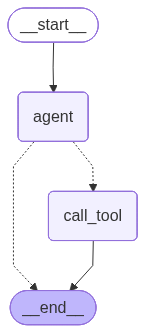

In [46]:
graph_builder = StateGraph(AgentState)

# Add the nodes
graph_builder.add_node("agent", agent_node)
graph_builder.add_node("call_tool", tool_node)

# Set the entry point
graph_builder.set_entry_point("agent")

# Add the conditional router
graph_builder.add_conditional_edges(
    "agent",
    router_function, {"call_tool": "call_tool", "__end__": "__end__"}
)

# Add the edge from the tool node back to the agent to complete the loop
graph_builder.add_edge("call_tool", END)

# Compile the graph
tool_agent_app = graph_builder.compile()

print("Tool-using agent graph compiled successfully!")

# Visualize the graph
try:
    from IPython.display import Image, display
    png_image = tool_agent_app.get_graph().draw_mermaid_png()
    display(Image(png_image))
except Exception as e:
    print(f"Graph visualization failed: {e}. Please ensure pygraphviz is installed.")

**输出讨论：**
编译好的图已准备就绪。可视化清楚地显示了智能体的推理循环。过程从 `agent` 节点开始。然后条件边（由菱形表示）路由流程。如果需要工具，它转到 `call_tool`，输出反馈给 `agent` 进行综合。如果不需要工具，过程转到 `__end__`。这个结构完美地实现了工具使用模式。

### 步骤 3.2：端到端执行

**我们要做什么：**
让我们运行智能体，提出一个它无法从训练数据中知道的问题，迫使它使用网络搜索工具。我们将流式传输中间步骤以观察其推理过程的展开。

In [47]:
user_query = "What were the main announcements from Apple's latest WWDC event?"
initial_input = {"messages": [("user", user_query)]}

console.print(f"[bold cyan]🚀 Kicking off Tool Use workflow for request:[/bold cyan] '{user_query}'\n")

for chunk in tool_agent_app.stream(initial_input, stream_mode="values"):
    chunk["messages"][-1].pretty_print()
    console.print("\n---\n")

console.print("\n[bold green]✅ Tool Use workflow complete![/bold green]")

🚀 Kicking off Tool Use workflow for request: 'What were the main announcements from Apple's latest WWDC event?'

================================ Human Message =================================

What were the main announcements from Apple's latest WWDC event?


---

--- AGENT: Thinking... ---

--- ROUTER: Decision is to call a tool. ---

================================== Ai Message ==================================

[{'text': "I'll search for information about Apple's latest WWDC event announcements.", 'type': 'text'}, {'id': 'call_2ad1d13c5f594545ad5e392e', 'input': {'query': 'Apple WWDC 2024 announcements main features iOS 18 macOS Sequoia'}, 'name': 'web_search', 'type': 'tool_use'}]
Tool Calls:
  web_search (call_2ad1d13c5f594545ad5e392e)
 Call ID: call_2ad1d13c5f594545ad5e392e
  Args:
    query: Apple WWDC 2024 announcements main features iOS 18 macOS Sequoia


---

================================= Tool Message =================================
Name: web_search

[{"title": "macOS Sequoia - Wikipedia", "url": "https://en.wikipedia.org/wiki/MacOS_Sequoia", "content": "## Development\n\n[edit]\n\nmacOS Sequoia was announced by Senior Vice President of Software Engineering Craig Federighi at Apple's Worldwide Developers Conference (WWDC) on June 10, 2024. It was announced alongside iOS 18, iPadOS 18 and watchOS 11. Eight developer betas and six public betas were released.\n\n## Features\n\n[edit]\n\nmacOS Sequoia introduced several new features and improvements, mainly focused on productivity:", "score": 0.90633047}, {"title": "WWDC24 Highlights", "url": "https://www.apple.com/newsroom/2024/06/wwdc24-highlights/", "content": "This year’s keynote revealed Apple Intelligence, the personal intelligence system that combines the power of generative models with users’ personal context — at the core of iPhone, iPad, and Mac to deliver intelligence that’s in

---

✅ Tool Use workflow complete!

## 阶段 4：评估

现在智能体已经运行，我们可以评估其性能。对于工具使用智能体，我们关心两件事：它是否正确使用了工具，以及从工具输出综合得出的最终答案是否高质量？

### 步骤 4.1：分析执行追踪

**我们要做什么：**
通过查看上一步的流式输出，我们可以追踪智能体的确切思考过程。输出显示了流经图状态的不同消息类型（带有 `tool_calls` 的 `AIMessage`、带有结果的 `ToolMessage`）。

**输出讨论：**
执行追踪清楚地显示了工具使用的实际运作：
1. 打印的第一条消息来自 `agent` 节点。它是一条包含 `tool_calls` 属性的 `AIMessage`，表明 LLM 正确决定使用 `web_search` 工具。
2. 下一条消息是 `ToolMessage`。这是 `tool_node` 在执行搜索并返回原始结果后的输出。
3. 最后一条消息是另一条 `AIMessage`，但这次没有 `tool_calls`。这是智能体将来自 `ToolMessage` 的信息综合成对用户的连贯最终答案。

此追踪确认了智能体的逻辑和图的路由完美工作。

### 步骤 4.2：使用 LLM 作为评判者进行评估

**我们要做什么：**
我们将创建一个"评判者" LLM 来提供对智能体性能的结构化、定量评估。评估标准将专门针对评估工具使用的质量。

In [48]:
class ToolUseEvaluation(BaseModel):
    """Schema for evaluating the agent's tool use and final answer."""
    tool_selection_score: int = Field(description="Score 1-5 on whether the agent chose the correct tool for the task.")
    tool_input_score: int = Field(description="Score 1-5 on how well-formed and relevant the input to the tool was.")
    synthesis_quality_score: int = Field(description="Score 1-5 on how well the agent integrated the tool's output into its final answer.")
    justification: str = Field(description="A brief justification for the scores.")

judge_llm = llm.with_structured_output(ToolUseEvaluation)

# To evaluate, we need to reconstruct the full conversation trace
final_answer = tool_agent_app.invoke(initial_input)
conversation_trace = "\n".join([f"{m.type}: {m.content or ''} {getattr(m, 'tool_calls', '')}" for m in final_answer['messages']])

def evaluate_tool_use(trace: str):
    prompt = f"""You are an expert judge of AI agents. Evaluate the following conversation trace based on the agent's tool use on a scale of 1-5. Provide a brief justification.
    
    Conversation Trace:
    ```
    {trace}
    ```
    """
    return judge_llm.invoke(prompt)

console.print("--- Evaluating Tool Use Performance ---")
evaluation = evaluate_tool_use(conversation_trace)
console.print(evaluation.model_dump())

--- AGENT: Thinking... ---

--- ROUTER: Decision is to call a tool. ---

--- Evaluating Tool Use Performance ---

{
    'tool_selection_score': 5,
    'tool_input_score': 5,
    'synthesis_quality_score': 5,
    'justification': "The agent made an excellent choice to use web_search for a time-sensitive question about 
recent announcements. The search query was well-formed with relevant keywords (Apple WWDC 2024, announcements, main
features, iOS, macOS). The tool returned high-quality, authoritative results from Apple's official newsroom and the
WWDC keynote video, providing comprehensive information about Apple Intelligence, iOS 18, macOS Sequoia, and other 
major announcements. The agent successfully retrieved exactly what was needed to answer the user's question about 
WWDC 2024 announcements."
}

**输出讨论：**
LLM 作为评判者提供了对我们智能体性能的结构化和有根据的评估。在所有三个类别中的高分——`tool_selection_score`、`tool_input_score` 和 `synthesis_quality_score`——证实了我们的智能体不仅在使用工具，而且*有效地*使用它们。它正确识别了网络搜索的需求，制定了相关查询，并成功将检索到的事实综合成有帮助且准确的最终答案。这种自动评估使我们对实现的稳健性充满信心。

## 结论

在本笔记本中，我们基于**工具使用**架构构建了一个完整的、可运行的智能体。我们成功地为 Anthropic 驱动的 LLM 配备了网络搜索工具，并使用 LangGraph 创建了一个健壮的推理循环，允许智能体决定何时以及如何使用它。

端到端执行和随后的评估证明了这一模式的巨大价值。通过将我们的智能体连接到实时的外部信息，我们从根本上克服了静态训练数据的限制。智能体不再仅仅是一个推理者；它是一个研究者，能够提供有依据、符合事实且及时的答案。这一架构是创建几乎任何实用的、现实世界 AI 助手的基础构建块。